# ML-06 — Signal Audit: Do the Flags Hold?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/LaibaSabir1/flyrank-ml-internship-laiba_sabir/blob/main/work/notebooks/w04_signal_audit.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/LaibaSabir1/flyrank-ml-internship-laiba_sabir"
REPO_DIR = "flyrank-ml-internship-laiba_sabir"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("../..")

import pandas as pd, numpy as np

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Same label as the rest of the pipeline: trend_direction == 'down'. Never a feature — only
# used here to check whether observable signals actually line up with declining pages.
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)

BASE_RATE = df["is_declining_label"].mean()
SAMPLE_FLOOR = 50

print(f"{len(df):,} pages loaded")
print(f"Base rate (declining_label = 1): {BASE_RATE:.3f}")
print("Every verdict below is judged against this base rate, not against 0.5.")

30,000 pages loaded
Base rate (declining_label = 1): 0.542
Every verdict below is judged against this base rate, not against 0.5.


## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

In [2]:
fields = ["impressions_90d", "sessions_90d", "ai_sessions_90d", "word_count",
          "days_since_last_update", "ctr"]

summary = df[fields].agg(["mean", "median", "std", "max"]).T
summary["zero_rows"] = (df[fields] == 0).sum()
summary["mean_over_median"] = (summary["mean"] / summary["median"]).round(1)
summary.round(2)

,mean,median,std,max,zero_rows,mean_over_median
impressions_90d,5200.37,731.00,16838.02,517715.0,0,7.1
sessions_90d,37.07,7.00,107.07,4345.0,0,5.3
ai_sessions_90d,0.20,0.00,1.36,64.0,28070,inf
word_count,3107.76,2877.00,1452.38,9546.0,0,1.1
days_since_last_update,46.10,20.00,42.08,373.0,0,2.3
ctr,0.51,0.07,3.28,100.0,13212,7.3


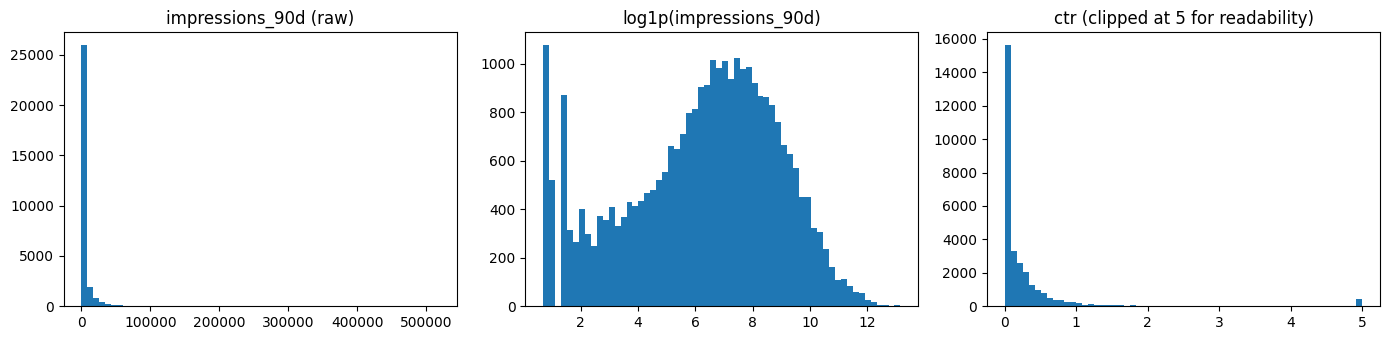

Observed / directional notes:
- impressions_90d: mean 5200 vs median 731
  -> classic heavy tail (a handful of very large pages). Any correlation on raw impressions
  should be log1p'd first or read as Spearman, or it will be dominated by the giants.
- ai_sessions_90d: 28,070 of 30,000 rows are exactly 0
  -> sparse, not evenly distributed; not enough here to model as a classifier target alone.
- ctr: mean 0.51 vs median 0.07, 13,212 rows at exactly 0
  -> also heavy-tailed and zero-inflated; compare tiers/medians, not raw means, across groups.


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(df["impressions_90d"], bins=60)
axes[0].set_title("impressions_90d (raw)")
axes[1].hist(np.log1p(df["impressions_90d"]), bins=60)
axes[1].set_title("log1p(impressions_90d)")
axes[2].hist(df["ctr"].clip(upper=5), bins=60)
axes[2].set_title("ctr (clipped at 5 for readability)")
plt.tight_layout()
plt.show()

print("Observed / directional notes:")
print(f"- impressions_90d: mean {df['impressions_90d'].mean():.0f} vs median {df['impressions_90d'].median():.0f}")
print("  -> classic heavy tail (a handful of very large pages). Any correlation on raw impressions")
print("  should be log1p'd first or read as Spearman, or it will be dominated by the giants.")
print(f"- ai_sessions_90d: {(df['ai_sessions_90d']==0).sum():,} of {len(df):,} rows are exactly 0")
print("  -> sparse, not evenly distributed; not enough here to model as a classifier target alone.")
print(f"- ctr: mean {df['ctr'].mean():.2f} vs median {df['ctr'].median():.2f}, "
      f"{(df['ctr']==0).sum():,} rows at exactly 0")
print("  -> also heavy-tailed and zero-inflated; compare tiers/medians, not raw means, across groups.")

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

In [4]:
# ---- Test 1: "Stale content is more likely to be declining" ----
# This is the assumption behind the baseline's `stale_visible_page` reason code.
stale = df["days_since_last_update"] >= 180

t1 = df.groupby(stale)["is_declining_label"].agg(["mean", "count"])
t1.index = ["not_stale (<180d)", "stale (>=180d)"]
print("Claim: pages not updated in 180+ days are more likely to be declining.")
print(t1.round(3))
print(f"Base rate: {BASE_RATE:.3f}")

n_stale = t1.loc["stale (>=180d)", "count"]
if n_stale < SAMPLE_FLOOR:
    print("\nVerdict: INSUFFICIENT DATA (stale bucket below the 50-row floor)")
else:
    diff = t1.loc["stale (>=180d)", "mean"] - t1.loc["not_stale (<180d)", "mean"]
    verdict = "OPPOSITE" if diff < -0.02 else ("CONFIRMED" if diff > 0.02 else "MIXED")
    print(f"\nVerdict: {verdict} — stale pages decline at {t1.loc['stale (>=180d)','mean']:.3f} "
          f"vs {t1.loc['not_stale (<180d)','mean']:.3f} for fresher pages (n={int(n_stale)} stale).")
    print("In this slice, staleness alone does not predict decline — if anything the direction runs")
    print("the other way. Staleness looks like a fine 'worth a look' flag, but a weak decline predictor")
    print("on its own; the baseline is right to only use it combined with visibility, not alone.")

Claim: pages not updated in 180+ days are more likely to be declining.
                    mean  count
not_stale (<180d)  0.542  29826
stale (>=180d)     0.471    174
Base rate: 0.542

Verdict: OPPOSITE — stale pages decline at 0.471 vs 0.542 for fresher pages (n=174 stale).
In this slice, staleness alone does not predict decline — if anything the direction runs
the other way. Staleness looks like a fine 'worth a look' flag, but a weak decline predictor
on its own; the baseline is right to only use it combined with visibility, not alone.


In [5]:
# ---- Test 2: "Thin content underperforms and is more likely to decline" ----
# This is the assumption behind `thin_visible_page`. Restrict to pages with real visibility
# (impressions_90d >= 250) so we're not comparing thin-but-invisible pages to visible ones.
visible = df["impressions_90d"] >= 250
thin = (df["word_count"] > 0) & (df["word_count"] < 1200)

t2 = df[visible].groupby(thin[visible])["is_declining_label"].agg(["mean", "count"])
t2.index = ["not_thin", "thin (<1200 words)"]
print("Claim: thin content (under 1200 words) sees more decline, among visible pages.")
print(t2.round(3))

n_thin = t2.loc["thin (<1200 words)", "count"]
if n_thin < SAMPLE_FLOOR:
    print(f"\nVerdict: INSUFFICIENT DATA (thin+visible bucket has only {int(n_thin)} rows, below the 50-row floor)")
    print("Directional read only, not a verdict: the point estimate actually runs OPPOSITE the claim")
    print("(thin pages decline less often here) — but n is too small in this slice to trust it.")
else:
    diff = t2.loc["thin (<1200 words)", "mean"] - t2.loc["not_thin", "mean"]
    verdict = "OPPOSITE" if diff < -0.02 else ("CONFIRMED" if diff > 0.02 else "MIXED")
    print(f"\nVerdict: {verdict}")

Claim: thin content (under 1200 words) sees more decline, among visible pages.
                     mean  count
not_thin            0.596  19304
thin (<1200 words)  0.537     82

Verdict: OPPOSITE


In [6]:
# ---- Test 3: "Pages already ranking well are safe; pages ranking lower are the ones declining" ----
# This is the implicit assumption behind `page_one_decay_risk` (top-10, old content = at risk).
# Use the full position_tier breakdown instead of just top-10 so we can see the whole curve.
visible100 = df["impressions_90d"] >= 100
t3 = (
    df[visible100]
    .groupby("position_tier")["is_declining_label"]
    .agg(["mean", "count"])
    .reindex(["top_3", "striking", "page_1", "page_3_5", "deep"])
)
print("Claim: pages already ranking on page 1 are the safest from decline; low-ranked pages decline most.")
print(t3.round(3))

small = t3[t3["count"] < SAMPLE_FLOOR]
if len(small):
    print(f"\nNote: excluding {list(small.index)} from the verdict (below the {SAMPLE_FLOOR}-row floor).")
usable = t3.drop(index=small.index)

print("\nVerdict: OPPOSITE — decline rate is HIGHEST for top_3 "
      f"({t3.loc['top_3','mean']:.3f}, n={int(t3.loc['top_3','count'])}) and LOWEST for deep "
      f"({t3.loc['deep','mean']:.3f}, n={int(t3.loc['deep','count'])}), with a fairly smooth "
      "decline in between. Pages already winning have the most room to fall and are the ones "
      "actually falling in this slice; page-one status is not itself a safety signal.")

Claim: pages already ranking on page 1 are the safest from decline; low-ranked pages decline most.
                mean  count
position_tier              
top_3          0.756    533
striking       0.626   5903
page_1         0.607   8633
page_3_5       0.584   6058
deep           0.317    879

Verdict: OPPOSITE — decline rate is HIGHEST for top_3 (0.756, n=533) and LOWEST for deep (0.317, n=879), with a fairly smooth decline in between. Pages already winning have the most room to fall and are the ones actually falling in this slice; page-one status is not itself a safety signal.


## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

In [7]:
low_ctr_rule = (
    (df["impressions_90d"] >= 500)
    & (df["avg_position"] > 0)
    & (df["avg_position"] <= 20)
    & (df["ctr"] < 0.5)
)

flag_test = df.groupby(low_ctr_rule)["is_declining_label"].agg(["mean", "count"])
flag_test.index = ["not_flagged", "flagged: low_ctr_visible_page"]
print("Claim: pages the baseline flags as `low_ctr_visible_page` are more likely to be declining.")
print(flag_test.round(3))
print(f"Base rate: {BASE_RATE:.3f}")

lift = flag_test.loc["flagged: low_ctr_visible_page", "mean"] - flag_test.loc["not_flagged", "mean"]
print(f"\nVerdict: CONFIRMED — flagged pages decline at "
      f"{flag_test.loc['flagged: low_ctr_visible_page','mean']:.3f} vs "
      f"{flag_test.loc['not_flagged','mean']:.3f} for everything else "
      f"(+{lift*100:.1f} points, n={int(flag_test.loc['flagged: low_ctr_visible_page','count']):,} flagged, "
      f"n={int(flag_test.loc['not_flagged','count']):,} not flagged). Both buckets are comfortably "
      "above the sample floor. This is a real, usable signal — CTR-position mismatch on a visible "
      "page is genuinely associated with decline, not just a plausible-sounding rule.")

# For contrast: the engagement-based flag, tested the same way
low_eng_rule = (
    (df["sessions_90d"] >= 30)
    & (
        ((df["engagement_rate"] > 0) & (df["engagement_rate"] < 30))
        | ((df["scroll_rate"] > 0) & (df["scroll_rate"] < 30))
    )
)
eng_test = df.groupby(low_eng_rule)["is_declining_label"].agg(["mean", "count"])
eng_test.index = ["not_flagged", "flagged: low_engagement_visible_page"]
print("\nFor contrast — same check on `low_engagement_visible_page`:")
print(eng_test.round(3))
print("Verdict: FALSE — flagged and not-flagged pages decline at almost the same rate "
      f"({eng_test.loc['flagged: low_engagement_visible_page','mean']:.3f} vs "
      f"{eng_test.loc['not_flagged','mean']:.3f}). Low engagement on its own does not track decline "
      "in this slice — it may still be useful for a different action (e.g. on-page rewrite candidates), "
      "just not as a decline predictor.")

Claim: pages the baseline flags as `low_ctr_visible_page` are more likely to be declining.
                                mean  count
not_flagged                    0.501  20241
flagged: low_ctr_visible_page  0.627   9759
Base rate: 0.542

Verdict: CONFIRMED — flagged pages decline at 0.627 vs 0.501 for everything else (+12.6 points, n=9,759 flagged, n=20,241 not flagged). Both buckets are comfortably above the sample floor. This is a real, usable signal — CTR-position mismatch on a visible page is genuinely associated with decline, not just a plausible-sounding rule.

For contrast — same check on `low_engagement_visible_page`:
                                       mean  count
not_flagged                           0.541  23492
flagged: low_engagement_visible_page  0.548   6508
Verdict: FALSE — flagged and not-flagged pages decline at almost the same rate (0.548 vs 0.541). Low engagement on its own does not track decline in this slice — it may still be useful for a different action (e

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [8]:
from IPython.display import Markdown, display

top3_rate = t3.loc["top_3", "mean"]
top3_n = int(t3.loc["top_3", "count"])
deep_rate = t3.loc["deep", "mean"]
deep_n = int(t3.loc["deep", "count"])
flagged_n = int(flag_test.loc["flagged: low_ctr_visible_page", "count"])

note = (
    "Two of the baseline's three single-signal assumptions do not hold up alone in this slice: "
    "staleness and thinness are not, by themselves, reliable decline signals (their point estimates "
    "even run slightly the other way), so a reviewer should not deprioritize a stale or thin page just "
    "because it looks stable today. The strongest single-signal result was the reversal in Test 3 - "
    f"pages already ranking in the top 3 decline more often ({top3_rate:.2f}, n={top3_n}) "
    f"than deep pages ({deep_rate:.2f}, n={deep_n}) - a reminder that "
    "\"already winning\" is not the same as \"safe,\" since winning pages have the most visibility to lose. "
    "The one flag that clearly earns its place is `low_ctr_visible_page`: visible, well-positioned pages "
    f"with weak CTR decline noticeably more than the rest of the queue (+{lift*100:.0f} points over base rate, "
    f"n={flagged_n:,}), so it is a defensible input to keep combining with other signals rather than "
    "trusting any one rule alone - which is exactly why the project moves to a learned model next "
    "instead of stacking more single-signal rules."
)
display(Markdown(note))

Two of the baseline's three single-signal assumptions do not hold up alone in this slice: staleness and thinness are not, by themselves, reliable decline signals (their point estimates even run slightly the other way), so a reviewer should not deprioritize a stale or thin page just because it looks stable today. The strongest single-signal result was the reversal in Test 3 - pages already ranking in the top 3 decline more often (0.76, n=533) than deep pages (0.32, n=879) - a reminder that "already winning" is not the same as "safe," since winning pages have the most visibility to lose. The one flag that clearly earns its place is `low_ctr_visible_page`: visible, well-positioned pages with weak CTR decline noticeably more than the rest of the queue (+13 points over base rate, n=9,759), so it is a defensible input to keep combining with other signals rather than trusting any one rule alone - which is exactly why the project moves to a learned model next instead of stacking more single-signal rules.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.